# Delivery Time Regression with a Neural Network

This notebook trains a neural network model to predict `delivery_time_mins` from `data.pkl`.

The notebook contains :
- data loading and validation
- leakage-safe preprocessing and feature engineering
- scaling and encoding
- neural network training and evaluation
- baseline comparison and artifact saving
- inference on new samples

### Set Up Environment and Imports

Import core libraries, configure plotting, and set seeds for reproducibility.

In [1]:
import json
import random
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import callbacks, layers


SEED = 69
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

### Load and Validate Dataset

Load the dataset, inspect shape and data types, and profile missing values, duplicates, and target distribution.

In [2]:
DATA_PATH = Path("data.pkl")

df = pd.read_pickle(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())

dtypes_df = (
    df.dtypes.rename("dtype")
    .to_frame()
    .assign(non_null_count=df.notna().sum().values)
    .assign(null_count=df.isna().sum().values)
)
display(dtypes_df)


print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Missing values: {dtypes_df['null_count'].sum()}")

Dataset shape: (174190, 14)


,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,delivery_time_mins
0,1,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1,4,3441,4,557,1239,33,14,21,47
1,2,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2,1,1900,1,1400,1400,1,2,2,44
2,2,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3,4,4771,3,820,1604,8,6,18,55
3,1,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1,1,1525,1,1525,1525,5,6,8,59
4,1,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1,2,3620,2,1425,2195,5,5,7,46


,dtype,non_null_count,null_count
market_id,int8,174190,0
created_at,datetime64[ns],174190,0
actual_delivery_time,datetime64[ns],174190,0
store_primary_category,category,174190,0
order_protocol,int8,174190,0
total_items,int32,174190,0
subtotal,int32,174190,0
num_distinct_items,int32,174190,0
min_item_price,int32,174190,0
max_item_price,int32,174190,0


Duplicate rows: 0
Missing values: 0


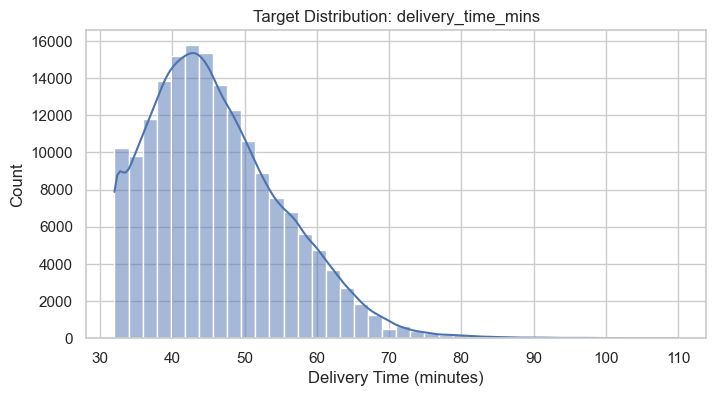

Skewness: 0.76
Kurtosis: 0.61


In [3]:
# target distribution

plt.figure(figsize=(8, 4))
sns.histplot(df["delivery_time_mins"], kde=True, bins=40)
plt.title("Target Distribution: delivery_time_mins")
plt.xlabel("Delivery Time (minutes)")
plt.show()

print(f"Skewness: {df['delivery_time_mins'].skew():.2f}")
print(f"Kurtosis: {df['delivery_time_mins'].kurtosis():.2f}")

### Separate Features and Target (`delivery_time_mins`)

Create feature matrix and target vector

In [4]:
TARGET_COL = "delivery_time_mins"

df_model = df.copy()

X_raw = df_model.drop(columns=[TARGET_COL])
y_raw = df_model[TARGET_COL].astype(float)

print(f"Feature matrix shape: {X_raw.shape}")
print(f"Target vector shape: {y_raw.shape}\n")
display(y_raw.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]))

Feature matrix shape: (174190, 13)
Target vector shape: (174190,)



count    174190.000000
mean         46.216006
std           9.331742
min          32.000000
1%           32.000000
25%          39.000000
50%          45.000000
75%          52.000000
99%          72.000000
max         110.000000
Name: delivery_time_mins, dtype: float64

### Split Data into Train/Validation/Test Sets

Split with fixed random seed and keep validation and test hold-outs separate to avoid leakage.

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw,
    y_raw,
    test_size=0.3,
    random_state=SEED,
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=SEED,
)

print("Split sizes:")
print(f"Train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Test: {X_test.shape}, y_test: {y_test.shape}")
print(f"Validation: {X_val.shape}, y_val: {y_val.shape}")

Split sizes:
Train: (121933, 13), y_train: (121933,)
Test: (26128, 13), y_test: (26128,)
Validation: (26129, 13), y_val: (26129,)


In [6]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 121933 entries, 31409 to 123163
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   market_id                 121933 non-null  int8          
 1   created_at                121933 non-null  datetime64[ns]
 2   actual_delivery_time      121933 non-null  datetime64[ns]
 3   store_primary_category    121933 non-null  category      
 4   order_protocol            121933 non-null  int8          
 5   total_items               121933 non-null  int32         
 6   subtotal                  121933 non-null  int32         
 7   num_distinct_items        121933 non-null  int32         
 8   min_item_price            121933 non-null  int32         
 9   max_item_price            121933 non-null  int32         
 10  total_onshift_dashers     121933 non-null  int32         
 11  total_busy_dashers        121933 non-null  int32         
 12  tot

### Implement Data Cleaning and Type Handling

Standardize column names, infer datetime fields safely from training data, and define imputation policies.

In [7]:
# Infer datetime columns from training split only
datetime_cols = X_train.select_dtypes(include='datetime').columns.tolist()
numeric_cols_pre = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_pre = [
    c for c in X_train.columns if c not in numeric_cols_pre and c not in datetime_cols
]

print(f"Datetime columns: {len(datetime_cols)}")
print(datetime_cols)
print(f"Numeric columns before feature engineering: {len(numeric_cols_pre)}")
print(numeric_cols_pre)
print(
    f"Categorical columns before feature engineering: {len(categorical_cols_pre)}")
print(categorical_cols_pre)

Datetime columns: 2
['created_at', 'actual_delivery_time']
Numeric columns before feature engineering: 10
['market_id', 'order_protocol', 'total_items', 'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders']
Categorical columns before feature engineering: 1
['store_primary_category']


### Create Feature Engineering Pipeline

Build a custom, leakage-safe transformer for datetime decomposition, cyclical encoding, interaction features, and aggregate order signals.

In [8]:
class DeliveryFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        datetime_cols=None,
        max_numeric_interactions: int = 3,
        add_interactions: bool = True,
        drop_after_fe=None,
    ):
        self.datetime_cols = datetime_cols or []
        self.max_numeric_interactions = max_numeric_interactions
        self.add_interactions = add_interactions
        self.drop_after_fe = drop_after_fe or [
            "created_at", "actual_delivery_time"]

    def fit(self, X: pd.DataFrame, y=None):
        X = X.copy()
        self.drop_after_fe_ = [c for c in self.drop_after_fe if c in X.columns]

        # Exclude leakage-prone datetime columns from derived datetime features.
        self.datetime_cols_ = [
            c for c in self.datetime_cols
            if c in X.columns and c not in self.drop_after_fe_
        ]

        # Persist all learned column groups so transform is always safe.
        numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
        max_cols = max(0, int(self.max_numeric_interactions))
        self.interaction_cols_ = numeric_cols[:max_cols]
        self.distance_cols_ = [
            c for c in X.columns if "distance" in c.lower()
        ]
        self.quantity_cols_ = [
            c
            for c in X.columns
            if any(k in c.lower() for k in ["qty", "quantity", "count", "items", "item"])
        ]
        return self

    def transform(self, X: pd.DataFrame):
        X = X.copy()

        # Datetime decomposition and cyclical encoding
        for col in self.datetime_cols_:
            dt = X[col]
            X[f"{col}_year"] = dt.dt.year
            X[f"{col}_month"] = dt.dt.month
            X[f"{col}_day"] = dt.dt.day
            X[f"{col}_hour"] = dt.dt.hour
            X[f"{col}_dayofweek"] = dt.dt.dayofweek
            X[f"{col}_is_weekend"] = dt.dt.dayofweek.isin([5, 6]).astype(float)

            hour = dt.dt.hour.fillna(0)
            dow = dt.dt.dayofweek.fillna(0)
            X[f"{col}_hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
            X[f"{col}_hour_cos"] = np.cos(2 * np.pi * hour / 24.0)
            X[f"{col}_dow_sin"] = np.sin(2 * np.pi * dow / 7.0)
            X[f"{col}_dow_cos"] = np.cos(2 * np.pi * dow / 7.0)

            X = X.drop(columns=[col])

        # Generic numeric interactions among first few numeric fields
        if self.add_interactions and len(self.interaction_cols_) >= 2:
            eps = 1e-6
            for i in range(len(self.interaction_cols_) - 1):
                for j in range(i + 1, len(self.interaction_cols_)):
                    c1, c2 = self.interaction_cols_[
                        i], self.interaction_cols_[j]
                    if c1 in X.columns and c2 in X.columns:
                        X[f"{c1}_x_{c2}"] = X[c1].astype(
                            float) * X[c2].astype(float)
                        X[f"{c1}_div_{c2}"] = X[c1].astype(
                            float) / (X[c2].astype(float) + eps)

        # Distance bins if distance-like columns exist
        for col in self.distance_cols_:
            if col in X.columns:
                X[f"{col}_bin"] = pd.cut(
                    X[col],
                    bins=[-np.inf, 1, 3, 5, 10, np.inf],
                    labels=["very_near", "near", "mid", "far", "very_far"],
                ).astype(str)

        # Aggregate order characteristics when quantity/count-like columns exist
        present_qty_cols = [c for c in self.quantity_cols_ if c in X.columns]
        if present_qty_cols:
            X["aggregate_order_size"] = X[present_qty_cols].sum(axis=1)

        # Explicitly remove leakage-prone time columns after feature engineering.
        cols_to_drop = [c for c in self.drop_after_fe_ if c in X.columns]
        if cols_to_drop:
            X = X.drop(columns=cols_to_drop)

        return X

### Build Preprocessing Pipeline (Encoding + Scaling)

Create a reusable sklearn pipeline that imputes, scales numeric features, and one-hot encodes categorical features.

In [9]:
from sklearn.compose import make_column_selector

# preprocessing defaults
numeric_impute_strategy = "median"
categorical_impute_strategy = "most_frequent"


def make_onehot_encoder():
    return OneHotEncoder(handle_unknown="ignore", sparse_output=True)


def build_preprocessor():
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy=numeric_impute_strategy)),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy=categorical_impute_strategy)),
            ("onehot", make_onehot_encoder()),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, make_column_selector(dtype_include=np.number)),
            ("cat", categorical_pipeline,
             make_column_selector(dtype_exclude=np.number)),
        ],
        remainder="drop",
    )


baseline_pipeline = Pipeline(
    steps=[
        (
            "feature_engineering",
            DeliveryFeatureEngineer(
                datetime_cols=datetime_cols,
                max_numeric_interactions=3,
                add_interactions=True,
            ),
        ),
        ("preprocess", build_preprocessor()),
        ("model", LinearRegression()),
    ]
)

### Transform Data for Neural Network Input

Fit feature engineering and preprocessing on training data only, then transform validation/test and prepare dense float32 tensors.

In [10]:
feature_engineer = DeliveryFeatureEngineer(
    datetime_cols=datetime_cols,
    max_numeric_interactions=3,
    add_interactions=True,
)

X_train_fe = feature_engineer.fit_transform(X_train)
X_val_fe = feature_engineer.transform(X_val)
X_test_fe = feature_engineer.transform(X_test)

preprocessor = build_preprocessor()
X_train_prep = preprocessor.fit_transform(X_train_fe)
X_val_prep = preprocessor.transform(X_val_fe)
X_test_prep = preprocessor.transform(X_test_fe)


def to_dense(matrix):
    return matrix.toarray() if sparse.issparse(matrix) else np.asarray(matrix)


X_train_nn = to_dense(X_train_prep).astype(np.float32)
X_val_nn = to_dense(X_val_prep).astype(np.float32)
X_test_nn = to_dense(X_test_prep).astype(np.float32)

y_train_nn = y_train.to_numpy(dtype=np.float32)
y_val_nn = y_val.to_numpy(dtype=np.float32)
y_test_nn = y_test.to_numpy(dtype=np.float32)

print(f"X_train_nn shape: {X_train_nn.shape}")
print(f"X_val_nn shape: {X_val_nn.shape}")
print(f"X_test_nn shape: {X_test_nn.shape}")

X_train_nn shape: (121933, 88)
X_val_nn shape: (26129, 88)
X_test_nn shape: (26128, 88)


### Define Neural Network Regression Model

Create a dense neural network with dropout and batch normalization, and compile for regression.

In [11]:
def build_nn_model(
    input_dim: int,
    hidden_units=(256, 128, 64),
    dropout_rate: float = 0.2,
    learning_rate: float = 1e-3,
):
    model = keras.Sequential(name="delivery_time_regressor")
    model.add(layers.Input(shape=(input_dim,)))

    for units in hidden_units:
        model.add(layers.Dense(units, activation="relu"))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation="linear"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


nn_model = build_nn_model(input_dim=X_train_nn.shape[1])
nn_model.summary()

Model: "delivery_time_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,793 (257.00 KB)

 Trainable params: 64,897 (253.50 KB)

 Non-trainable params: 896 (3.50 KB)

### Train Model

Train with validation monitoring, early stopping, and learning-rate scheduling to reduce overfitting.

In [12]:
checkpoint_path = Path("best_nn_model.keras")

train_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
    ),
    callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_loss",
        save_best_only=True,
    ),
]

history = nn_model.fit(
    X_train_nn,
    y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=100,
    batch_size=64,
    callbacks=train_callbacks,
    verbose=1,
)

history_df = pd.DataFrame(history.history)
display(history_df.tail())

Epoch 1/100
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 418.2227 - mae: 14.0402 - val_loss: 26.6747 - val_mae: 3.9844 - learning_rate: 0.0010
Epoch 2/100
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 40.8633 - mae: 5.0103 - val_loss: 25.4072 - val_mae: 3.9268 - learning_rate: 0.0010
Epoch 3/100
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 37.5802 - mae: 4.8013 - val_loss: 24.7895 - val_mae: 3.8678 - learning_rate: 0.0010
Epoch 4/100
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 36.5138 - mae: 4.7321 - val_loss: 24.9677 - val_mae: 3.8679 - learning_rate: 0.0010
Epoch 5/100
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 35.8283 - mae: 4.6888 - val_loss: 24.7468 - val_mae: 3.8642 - learning_rate: 0.0010
Epoch 6/100
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 35.3285 - mae: 4.6532 - val_loss: 24.6410 - val_mae: 3.8473 - learning_rate: 0.0010
Epoch 7/100
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 35.1630 - mae: 4.6432 - val_loss: 24.7869 - val_mae: 

,loss,mae,val_loss,val_mae,learning_rate
10,34.140781,4.568982,25.047623,3.856511,0.001
11,34.110172,4.569763,24.744717,3.843665,0.001
12,33.878521,4.552222,24.676062,3.841316,0.001
13,33.668953,4.541325,24.674658,3.839937,0.001
14,33.510620,4.533594,24.572620,3.833541,0.001


### Evaluate Model Performance

Compute MAE, RMSE, and R2 on validation/test sets, compare to a linear baseline, and visualize fit quality.

,model,mae,rmse,r2
0,NeuralNet (val),3.838124,4.954430,0.712035
1,NeuralNet (test),3.891984,5.017623,0.708319
2,LinearBaseline (val),4.383283,5.557169,0.637708
3,LinearBaseline (test),4.398508,5.584636,0.638672


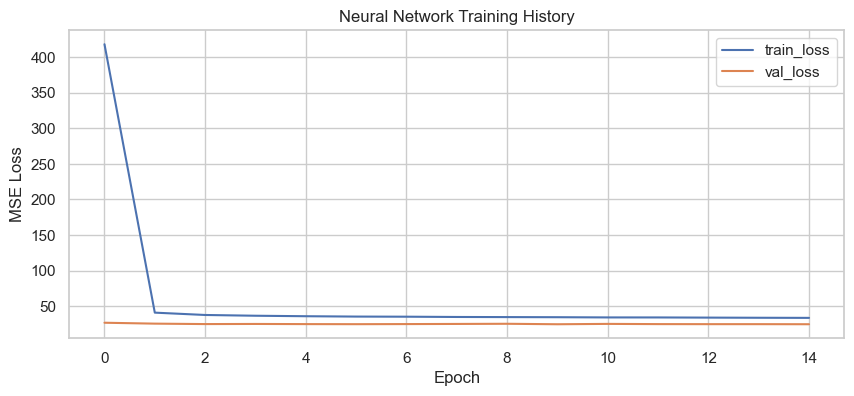

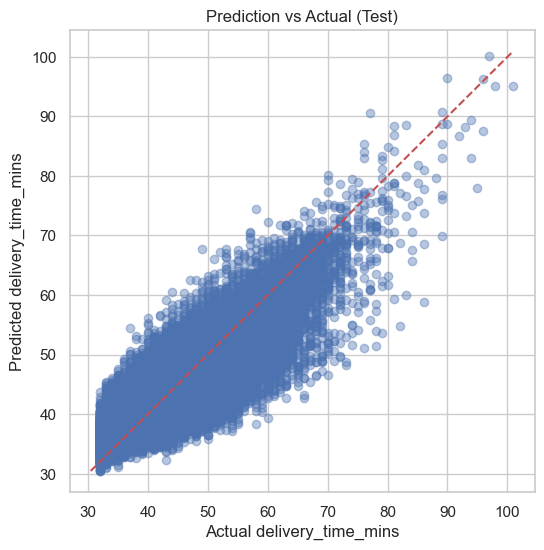

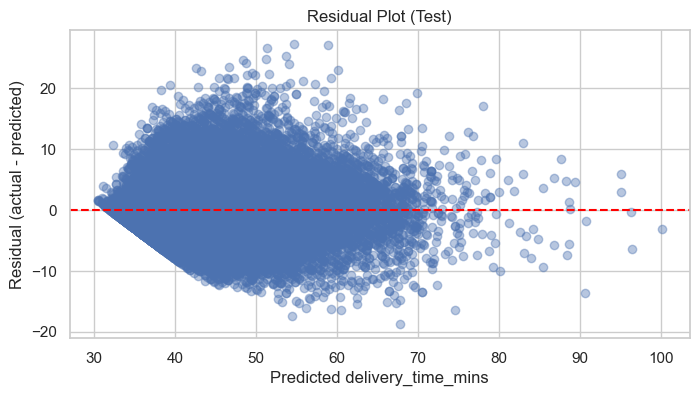

In [13]:
def regression_metrics(y_true, y_pred, model_name: str):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "model": model_name,
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": float(np.sqrt(mse)),
        "r2": r2_score(y_true, y_pred),
    }


nn_val_pred = nn_model.predict(X_val_nn, verbose=0).ravel()
nn_test_pred = nn_model.predict(X_test_nn, verbose=0).ravel()

nn_val_metrics = regression_metrics(y_val_nn, nn_val_pred, "NeuralNet (val)")
nn_test_metrics = regression_metrics(
    y_test_nn, nn_test_pred, "NeuralNet (test)")

# Baseline linear model using the same leakage-safe pipeline
baseline_pipeline.fit(X_train, y_train)
baseline_val_pred = baseline_pipeline.predict(X_val)
baseline_test_pred = baseline_pipeline.predict(X_test)

baseline_val_metrics = regression_metrics(
    y_val, baseline_val_pred, "LinearBaseline (val)")
baseline_test_metrics = regression_metrics(
    y_test, baseline_test_pred, "LinearBaseline (test)")

metrics_df = pd.DataFrame(
    [nn_val_metrics, nn_test_metrics, baseline_val_metrics, baseline_test_metrics]
)
display(metrics_df)

# Learning curves
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Neural Network Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# Prediction vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test_nn, nn_test_pred, alpha=0.4)
min_v = min(y_test_nn.min(), nn_test_pred.min())
max_v = max(y_test_nn.max(), nn_test_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], "r--")
plt.xlabel("Actual delivery_time_mins")
plt.ylabel("Predicted delivery_time_mins")
plt.title("Prediction vs Actual (Test)")
plt.show()

# Residual plot
residuals = y_test_nn - nn_test_pred
plt.figure(figsize=(8, 4))
plt.scatter(nn_test_pred, residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted delivery_time_mins")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual Plot (Test)")
plt.show()

### Feature Importance Diagnostics (Permutation Importance)

Estimate global feature importance for the fitted baseline pipeline by measuring validation-set performance drop when each feature is shuffled.

,feature,importance_mean,importance_std
0,total_outstanding_orders,7.967525,0.020124
1,total_onshift_dashers,3.236208,0.009684
2,total_busy_dashers,0.480476,0.002678
3,subtotal,0.137397,0.001513
4,order_protocol,0.032516,0.000927
5,num_distinct_items,0.029295,0.000963
6,market_id,0.015638,0.000644
7,store_primary_category,0.010343,0.000481
8,max_item_price,0.005491,0.000266
9,total_items,0.001421,0.000104


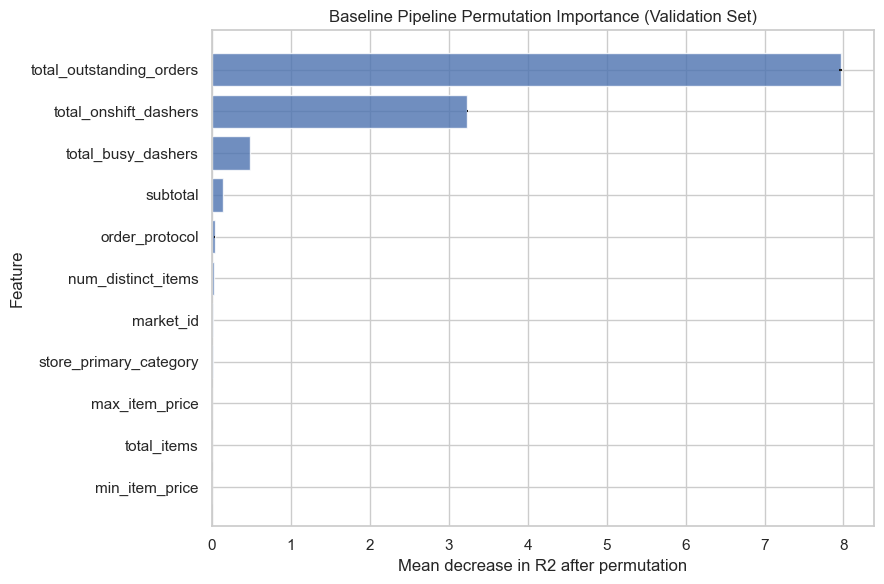

In [ ]:
from sklearn.inspection import permutation_importance

# Baseline pipeline was already fit above in the evaluation cell.
perm_result = permutation_importance(
    estimator=baseline_pipeline,
    X=X_val,
    y=y_val,
    scoring="r2",
    n_repeats=8,
    random_state=SEED,
    n_jobs=-1,
)

feature_importance_df = pd.DataFrame(
    {
        "feature": X_val.columns,
        "importance_mean": perm_result.importances_mean,
        "importance_std": perm_result.importances_std,
    }
).sort_values("importance_mean", ascending=False)

# Keep only positively contributing features for readability.
feature_importance_df = feature_importance_df[feature_importance_df["importance_mean"] > 0].reset_index(
    drop=True)

top_k = 10
display(feature_importance_df.head(top_k))

plot_df = feature_importance_df.head(top_k).iloc[::-1]
plt.figure(figsize=(9, 6))
plt.barh(plot_df["feature"], plot_df["importance_mean"],
         xerr=plot_df["importance_std"], alpha=0.8)
plt.xlabel("Mean decrease in R2 after permutation")
plt.ylabel("Feature")
plt.title("Baseline Pipeline Permutation Importance (Validation Set)")
plt.tight_layout()
plt.show()

### Hyperparameter Tuning (KerasTuner)

Run controlled experiments with `keras_tuner.RandomSearch` over architecture and optimization settings, then track and compare validation metrics.

In [15]:
import keras_tuner as kt


def build_tuner_model(hp):
    hidden_units_token = hp.Choice("hidden_units", values=[
                                   "256,128,64", "128,64"])
    hidden_units = tuple(int(x) for x in hidden_units_token.split(","))
    dropout_rate = hp.Choice("dropout_rate", values=[0.1, 0.25])
    learning_rate = hp.Choice("learning_rate", values=[1e-3, 5e-4])

    return build_nn_model(
        input_dim=X_train_nn.shape[1],
        hidden_units=hidden_units,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
    )


MAX_TUNING_TRIALS = 2
TUNER_EPOCHS = 40
batch_size_fixed = 64

# Overwrite previous tuner runs so this cell is reproducible.
tuner = kt.RandomSearch(
    hypermodel=build_tuner_model,
    objective=kt.Objective("val_mae", direction="min"),
    max_trials=MAX_TUNING_TRIALS,
    seed=SEED,
    directory="kt_tuning",
    project_name="delivery_time_regression",
    overwrite=True,
)

tuner_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
    )
]

try:
    tuner.search(
        X_train_nn,
        y_train_nn,
        validation_data=(X_val_nn, y_val_nn),
        epochs=TUNER_EPOCHS,
        batch_size=batch_size_fixed,
        callbacks=tuner_callbacks,
        verbose=0,
    )
except KeyboardInterrupt:
    print("Tuning interrupted. Using best completed trial(s) so far.")

best_trials = tuner.oracle.get_best_trials(num_trials=MAX_TUNING_TRIALS)
tuning_rows = []

for trial in best_trials:
    hp_values = trial.hyperparameters.values
    hidden_units = tuple(int(x) for x in hp_values["hidden_units"].split(","))

    val_mae = trial.metrics.get_last_value("val_mae")
    val_loss = trial.metrics.get_last_value("val_loss")
    val_rmse = float(np.sqrt(val_loss)) if val_loss is not None else np.nan

    tuning_rows.append(
        {
            "hidden_units": hidden_units,
            "dropout_rate": float(hp_values["dropout_rate"]),
            "learning_rate": float(hp_values["learning_rate"]),
            "batch_size": int(batch_size_fixed),
            "val_mae": float(val_mae) if val_mae is not None else np.nan,
            "val_rmse": val_rmse
        }
    )

tuning_results_df = pd.DataFrame(tuning_rows).sort_values(
    "val_rmse", ascending=True
).reset_index(drop=True)
display(tuning_results_df)

if tuning_results_df.empty:
    best_tuned_params = {}
else:
    best_row = tuning_results_df.iloc[0]
    best_tuned_params = {
        "hidden_units": tuple(best_row["hidden_units"]),
        "dropout_rate": float(best_row["dropout_rate"]),
        "learning_rate": float(best_row["learning_rate"]),
        "batch_size": int(best_row["batch_size"]),
        "val_mae": float(best_row["val_mae"]),
        "val_rmse": float(best_row["val_rmse"]),
    }

print("Best tuned params:")
print(best_tuned_params)

,hidden_units,dropout_rate,learning_rate,batch_size,val_mae,val_rmse
0,"(256, 128, 64)",0.10,0.0005,64,3.802966,4.905799
1,"(128, 64)",0.25,0.0010,64,3.797276,4.910518


Best tuned params:
{'hidden_units': (256, 128, 64), 'dropout_rate': 0.1, 'learning_rate': 0.0005, 'batch_size': 64, 'val_mae': 3.802966356277466, 'val_rmse': 4.905798824485493}


### Retrain Best Model and Save Artifacts

Retrain using selected hyperparameters and persist model, preprocessor, feature engineering transformer, and metadata for reproducible inference.

In [16]:
default_params = {
    "hidden_units": (256, 128, 64),
    "dropout_rate": 0.2,
    "learning_rate": 1e-3,
    "batch_size": 64,
}

if best_tuned_params:
    selected_params = {
        "hidden_units": tuple(best_tuned_params["hidden_units"]),
        "dropout_rate": float(best_tuned_params["dropout_rate"]),
        "learning_rate": float(best_tuned_params["learning_rate"]),
        "batch_size": int(best_tuned_params["batch_size"]),
    }
else:
    selected_params = default_params

X_trainval_nn = np.vstack([X_train_nn, X_val_nn])
y_trainval_nn = np.concatenate([y_train_nn, y_val_nn])

best_model = build_nn_model(
    input_dim=X_trainval_nn.shape[1],
    hidden_units=selected_params["hidden_units"],
    dropout_rate=selected_params["dropout_rate"],
    learning_rate=selected_params["learning_rate"],
)

final_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
    )
]

final_history = best_model.fit(
    X_trainval_nn,
    y_trainval_nn,
    validation_split=0.1,
    epochs=120,
    batch_size=selected_params["batch_size"],
    callbacks=final_callbacks,
    verbose=0,
)

final_test_pred = best_model.predict(X_test_nn, verbose=0).ravel()
final_test_metrics = regression_metrics(
    y_test_nn, final_test_pred, "Final NeuralNet (test)")
print(final_test_metrics)

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

joblib.dump(feature_engineer, ARTIFACT_DIR / "feature_engineer.joblib")
joblib.dump(preprocessor, ARTIFACT_DIR / "preprocessor.joblib")
best_model.save(ARTIFACT_DIR / "delivery_time_nn.keras")

metadata = {
    "target_column": TARGET_COL,
    "seed": SEED,
    "selected_params": {
        "hidden_units": list(selected_params["hidden_units"]),
        "dropout_rate": selected_params["dropout_rate"],
        "learning_rate": selected_params["learning_rate"],
        "batch_size": selected_params["batch_size"],
    },
    "test_metrics": {
        "mae": float(final_test_metrics["mae"]),
        "rmse": float(final_test_metrics["rmse"]),
        "r2": float(final_test_metrics["r2"]),
    },
    "renamed_columns": globals().get("rename_map", {}),
}

with open(ARTIFACT_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

{'model': 'Final NeuralNet (test)', 'mae': 3.859466552734375, 'rmse': 4.941017925700113, 'r2': 0.7171576023101807}


### SHAP Explainability Analysis

SHAP Analysis: Neural Network Delivery Time Model

Creating SHAP DeepExplainer with 100 background samples...
Computing SHAP values for 500 test samples...
SHAP values shape: (500, 88)
Generating SHAP summary plot...


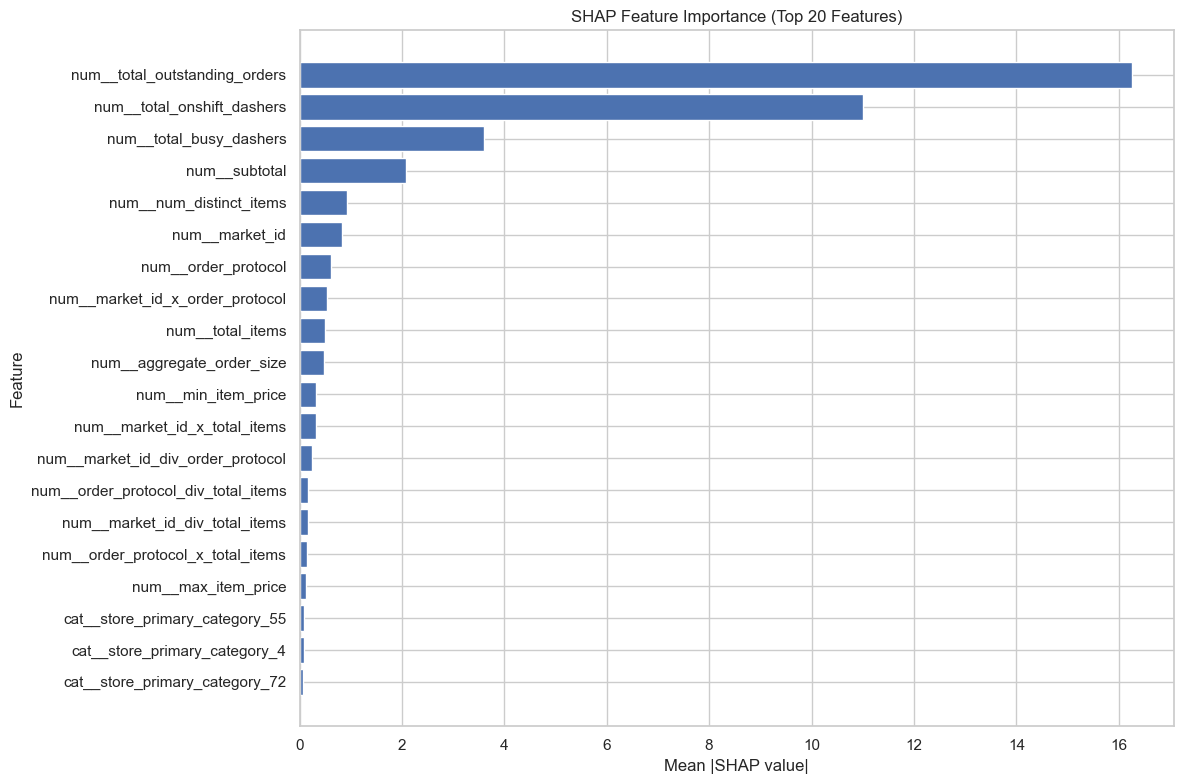


Top 20 Most Important Features by SHAP:
                            Feature  Mean |SHAP|
      num__total_outstanding_orders    16.266029
         num__total_onshift_dashers    11.010203
            num__total_busy_dashers     3.606835
                      num__subtotal     2.081982
            num__num_distinct_items     0.921012
                     num__market_id     0.823804
                num__order_protocol     0.613608
    num__market_id_x_order_protocol     0.541656
                   num__total_items     0.503653
          num__aggregate_order_size     0.473881
                num__min_item_price     0.330926
       num__market_id_x_total_items     0.325243
  num__market_id_div_order_protocol     0.253828
num__order_protocol_div_total_items     0.169934
     num__market_id_div_total_items     0.165730
  num__order_protocol_x_total_items     0.146632
                num__max_item_price     0.135633
     cat__store_primary_category_55     0.092109
      cat__store_primary_cat

In [17]:
import shap

print("SHAP Analysis: Neural Network Delivery Time Model\n")

feature_names = preprocessor.get_feature_names_out()
background_sample_size = min(100, len(X_train_nn))
background_sample = X_train_nn[:background_sample_size]
print(
    f"Creating SHAP DeepExplainer with {background_sample_size} background samples...")

# DeepExplainer expects model inputs with same shape as training tensor
explainer = shap.DeepExplainer(best_model, background_sample)

test_sample_size = min(500, len(X_test_nn))
test_sample = X_test_nn[:test_sample_size]
print(f"Computing SHAP values for {test_sample_size} test samples...")
shap_values_list = explainer.shap_values(test_sample)

if isinstance(shap_values_list, list):
    shap_values = shap_values_list[0]
else:
    shap_values = shap_values_list

shap_values = np.squeeze(shap_values)

print(f"SHAP values shape: {shap_values.shape}")

mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP|": mean_abs_shap,
}).sort_values("Mean |SHAP|", ascending=False).head(20)

print("Generating SHAP summary plot...")
plt.figure(figsize=(12, 8))
plt.barh(
    feature_importance["Feature"].iloc[::-1],
    feature_importance["Mean |SHAP|"].iloc[::-1],
)
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title("SHAP Feature Importance (Top 20 Features)")
plt.tight_layout()
plt.show()

print("\nTop 20 Most Important Features by SHAP:")
print(feature_importance.to_string(index=False))

example_idx = 0
expected_value_raw = explainer.expected_value
if isinstance(expected_value_raw, (list, tuple, np.ndarray)):
    expected_value = float(np.ravel(expected_value_raw)[0])
else:
    expected_value = float(expected_value_raw)

print(f"\nBase value (expected model output): {expected_value:.2f}")
print(
    f"Model prediction for sample {example_idx}: {final_test_pred[example_idx]:.2f}")
print(f"Actual delivery time: {y_test.iloc[example_idx]:.2f} mins")

top_features_idx = np.argsort(np.abs(shap_values[example_idx]))[-5:][::-1]
print(f"\nTop 5 contributing features for sample {example_idx}:")
for i, feat_idx in enumerate(top_features_idx):
    feature_name = feature_names[feat_idx]
    shap_contrib = shap_values[example_idx, feat_idx]
    print(f"  {i+1}. {feature_name}: SHAP value = {shap_contrib:.4f}")

### Run Inference on New Delivery Orders

Load saved artifacts, preprocess fresh records identically, and generate `delivery_time_mins` predictions.

In [26]:
loaded_feature_engineer = joblib.load(ARTIFACT_DIR / "feature_engineer.joblib")
loaded_preprocessor = joblib.load(ARTIFACT_DIR / "preprocessor.joblib")
loaded_model = keras.models.load_model(ARTIFACT_DIR / "delivery_time_nn.keras")

# Example: take a few unseen rows from test split as "new" orders
new_orders = X_test.sample(10).copy()
new_orders_fe = loaded_feature_engineer.transform(new_orders)
new_orders_prep = loaded_preprocessor.transform(new_orders_fe)
new_orders_nn = to_dense(new_orders_prep).astype(np.float32)

new_predictions = loaded_model.predict(new_orders_nn, verbose=0).ravel()

inference_df = new_orders.copy()
inference_df["predicted_delivery_time_mins"] = np.round(new_predictions, 2)
if isinstance(y_test, pd.Series):
    inference_df["actual_delivery_time_mins"] = y_test.loc[new_orders.index].values
cols_to_display = ["market_id", "total_onshift_dashers", "total_busy_dashers",
                   "predicted_delivery_time_mins", "actual_delivery_time_mins"]
display(inference_df[cols_to_display])

,market_id,total_onshift_dashers,total_busy_dashers,predicted_delivery_time_mins,actual_delivery_time_mins
76483,2,7,7,44.959999,38.0
142176,2,17,12,39.160000,40.0
50573,4,62,64,46.470001,45.0
118662,4,60,113,35.900002,35.0
127005,1,3,3,48.970001,40.0
41786,4,63,66,65.919998,67.0
161704,3,5,6,40.880001,40.0
159850,2,120,96,56.070000,49.0
118081,5,17,16,50.630001,50.0
135329,5,15,14,54.790001,57.0


In [27]:
np.abs(inference_df['predicted_delivery_time_mins'] - inference_df['actual_delivery_time_mins']).mean()

3.1010005950927733

In [28]:
((inference_df['predicted_delivery_time_mins'] - inference_df['actual_delivery_time_mins'])**2).mean()**0.5

4.35644022759469

For the random sample of 10 unseen orders, our model is able to achieve good delivery time predictions with the `mae = 3.1` and `rmse=4.3`, in line with our earlier observations on the test set.